# Chapter 4: Large Language Models for Biomedicine

## Hands-On Jupyter Notebook

This notebook builds an offline evaluation sandbox for biomedical LLM workflows in cancer research.

**Time to Complete**: 1-2 hours

**What You Will Build**
- A small oncology prompt-evaluation benchmark
- A structured-output workflow for biomedical extraction
- A comparison between loose prompting and grounded prompting
- A task-routing table for downstream agent tool use

---

## Section 1: Setup and Imports

This section configures the notebook and imports lightweight libraries for a local, reproducible biomedical LLM simulation workflow.

In [1]:
# Standard library imports
import json
import re
from textwrap import dedent
import warnings

warnings.filterwarnings('ignore')

# Data processing
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style='whitegrid', context='talk')

# Notebook display helpers
from IPython.display import display

# Configuration
plt.rcParams['figure.figsize'] = (12, 5)
np.random.seed(42)

print('Environment configured successfully for Chapter 4.')

Environment configured successfully for Chapter 4.


## Section 2: Build a Mini Biomedical Prompt Benchmark

We create a compact benchmark of oncology-oriented tasks. Each row includes evidence text, expected structured fields, and a suggested downstream tool category.

In [2]:
benchmark_rows = [
    {
        'case_id': 'case_01',
        'task_type': 'variant_interpretation',
        'tumor_type': 'lung adenocarcinoma',
        'gene': 'EGFR',
        'alteration': 'L858R',
        'evidence_text': (
            'A lung adenocarcinoma sample harbors EGFR L858R. '
            'The evidence note describes this as a sensitizing EGFR alteration in non-small cell lung cancer. '
            'The note recommends confirming therapy relevance with a curated knowledge base.'
        ),
        'expected_support_level': 'high',
        'preferred_tool': 'knowledge_base_lookup',
    },
    {
        'case_id': 'case_02',
        'task_type': 'literature_summarization',
        'tumor_type': 'pediatric high-grade glioma',
        'gene': 'H3F3A',
        'alteration': 'K27M',
        'evidence_text': (
            'A pediatric diffuse midline glioma case contains H3F3A K27M. '
            'The text links this alteration to pediatric high-grade glioma biology and recommends literature review before any therapeutic interpretation.'
        ),
        'expected_support_level': 'medium',
        'preferred_tool': 'literature_search',
    },
    {
        'case_id': 'case_03',
        'task_type': 'clinical_trial_screening',
        'tumor_type': 'breast cancer',
        'gene': 'ERBB2',
        'alteration': 'amplification',
        'evidence_text': (
            'The report states ERBB2 amplification in metastatic breast cancer. '
            'It suggests that trial matching should be based on receptor status, prior therapy, and formal eligibility review.'
        ),
        'expected_support_level': 'medium',
        'preferred_tool': 'trial_matching',
    },
    {
        'case_id': 'case_04',
        'task_type': 'cohort_question',
        'tumor_type': 'colorectal cancer',
        'gene': 'BRAF',
        'alteration': 'V600E',
        'evidence_text': (
            'The cohort note mentions BRAF V600E in colorectal cancer and recommends checking prevalence and co-alteration patterns in a cohort portal. '
            'No treatment claim is provided in the source note.'
        ),
        'expected_support_level': 'medium',
        'preferred_tool': 'cohort_portal_query',
    },
]

benchmark_df = pd.DataFrame(benchmark_rows)
display(benchmark_df[['case_id', 'task_type', 'tumor_type', 'gene', 'alteration', 'preferred_tool']])
print(f'Total benchmark cases: {len(benchmark_df)}')

,case_id,task_type,tumor_type,gene,alteration,preferred_tool
0,case_01,variant_interpretation,lung adenocarcinoma,EGFR,L858R,knowledge_base_lookup
1,case_02,literature_summarization,pediatric high-grade glioma,H3F3A,K27M,literature_search
2,case_03,clinical_trial_screening,breast cancer,ERBB2,amplification,trial_matching
3,case_04,cohort_question,colorectal cancer,BRAF,V600E,cohort_portal_query


Total benchmark cases: 4


## Section 3: Simulate LLM Outputs and Add Grounding Checks

This section compares two prompt styles:

- `loose_prompt`: fluent but unconstrained output
- `grounded_prompt`: constrained output schema with evidence-aware caveats

Because this notebook is self-contained, we simulate model outputs deterministically so the evaluation logic is reproducible offline.

In [3]:
def build_prompt(row: pd.Series, mode: str) -> str:
    base = dedent(f'''
    You are assisting with oncology evidence synthesis.
    Tumor type: {row['tumor_type']}
    Gene: {row['gene']}
    Alteration: {row['alteration']}
    Evidence text: {row['evidence_text']}
    ''').strip()

    if mode == 'loose_prompt':
        task = 'Provide a concise biomedical interpretation and likely clinical implications.'
    elif mode == 'grounded_prompt':
        task = dedent('''
        Return a JSON object with keys:
        - gene
        - alteration
        - tumor_type
        - evidence_statement
        - confidence
        - unsupported_claims_detected
        Rules:
        - Use only the provided evidence text.
        - If support is weak or absent for a claim, set unsupported_claims_detected to true.
        - Keep confidence as high, medium, or low.
        ''').strip()
    else:
        raise ValueError(f'Unknown mode: {mode}')

    return f"{base}\n\nTask:\n{task}"

def simulate_llm_output(row: pd.Series, mode: str) -> str:
    # Offline simulation to keep notebook deterministic and runnable without API keys.
    if mode == 'loose_prompt':
        if row['case_id'] == 'case_02':
            return (
                'H3F3A K27M is definitively targetable with approved therapy and ensures strong response in pediatric glioma.'
            )
        if row['case_id'] == 'case_04':
            return (
                'BRAF V600E in colorectal cancer indicates immediate treatment actionability and excellent prognosis.'
            )
        return (
            f"{row['gene']} {row['alteration']} in {row['tumor_type']} appears biologically relevant; "
            'clinical interpretation should be confirmed in curated resources.'
        )
    return json.dumps(
        {
            'gene': row['gene'],
            'alteration': row['alteration'],
            'tumor_type': row['tumor_type'],
            'evidence_statement': row['evidence_text'],
            'confidence': row['expected_support_level'],
            'unsupported_claims_detected': False,
        }
,
        ensure_ascii=False,
    )

unsupported_patterns = [
    r'definitively targetable',
    r'ensures strong response',
    r'immediate treatment actionability',
    r'excellent prognosis',
]

def detect_potential_hallucination(text: str) -> bool:
    lower_text = text.lower()
    return any(re.search(pattern, lower_text) for pattern in unsupported_patterns)

evaluation_rows = []
for _, row in benchmark_df.iterrows():
    for mode in ['loose_prompt', 'grounded_prompt']:
        prompt = build_prompt(row, mode)
        output = simulate_llm_output(row, mode)
        hallucination_flag = detect_potential_hallucination(output)
        evaluation_rows.append({
            'case_id': row['case_id'],
            'task_type': row['task_type'],
            'prompt_mode': mode,
            'preferred_tool': row['preferred_tool'],
            'prompt_chars': len(prompt),
            'output_chars': len(output),
            'potential_hallucination': hallucination_flag,
        })

evaluation_df = pd.DataFrame(evaluation_rows)
display(evaluation_df)

,case_id,task_type,prompt_mode,preferred_tool,prompt_chars,output_chars,potential_hallucination
0,case_01,variant_interpretation,loose_prompt,knowledge_base_lookup,438,130,False
1,case_01,variant_interpretation,grounded_prompt,knowledge_base_lookup,663,387,False
2,case_02,literature_summarization,loose_prompt,literature_search,423,108,True
3,case_02,literature_summarization,grounded_prompt,literature_search,648,374,False
4,case_03,clinical_trial_screening,loose_prompt,trial_matching,396,133,False
5,case_03,clinical_trial_screening,grounded_prompt,trial_matching,621,347,False
6,case_04,cohort_question,loose_prompt,cohort_portal_query,400,100,True
7,case_04,cohort_question,grounded_prompt,cohort_portal_query,625,351,False


## Section 4: Compare Prompt Strategies

We quantify hallucination-risk signals and output patterns across prompt modes.

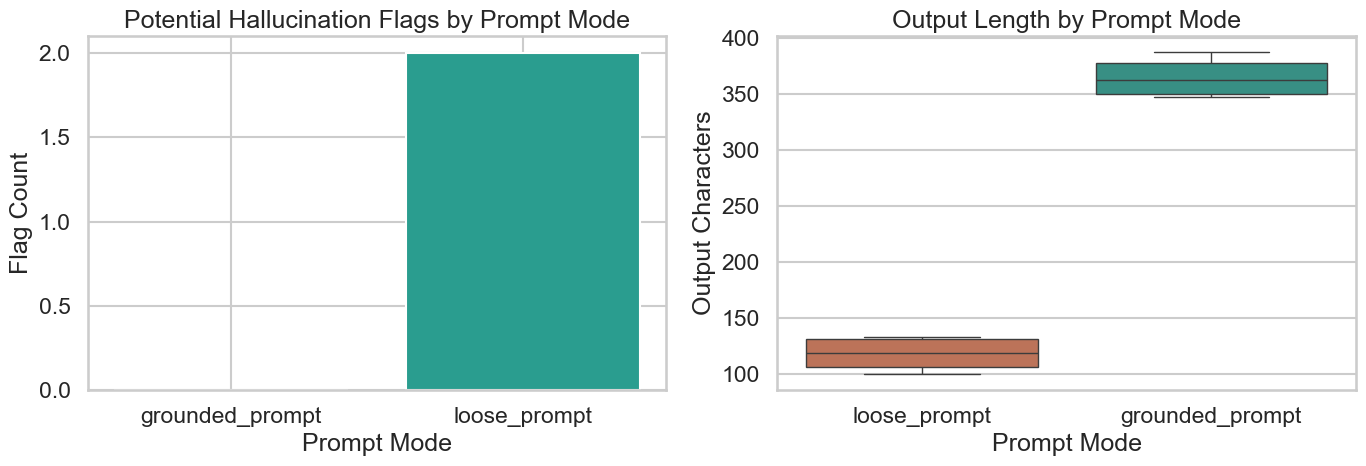

,prompt_mode,runs,potential_hallucinations,avg_output_chars,potential_hallucination_rate
0,grounded_prompt,4,0,364.75,0.0
1,loose_prompt,4,2,117.75,0.5


In [4]:
summary_df = (
    evaluation_df
    .groupby('prompt_mode', as_index=False)
    .agg(
        runs=('case_id', 'count'),
        potential_hallucinations=('potential_hallucination', 'sum'),
        avg_output_chars=('output_chars', 'mean'),
    )
)
summary_df['potential_hallucination_rate'] = (
    summary_df['potential_hallucinations'] / summary_df['runs']
).round(3)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: hallucination risk count by prompt mode
axes[0].bar(
    summary_df['prompt_mode'],
    summary_df['potential_hallucinations'],
    color=['#CC6B49', '#2A9D8F'],
)
axes[0].set_title('Potential Hallucination Flags by Prompt Mode')
axes[0].set_xlabel('Prompt Mode')
axes[0].set_ylabel('Flag Count')

# Plot 2: output length distribution by prompt mode
sns.boxplot(data=evaluation_df, x='prompt_mode', y='output_chars', ax=axes[1], palette=['#CC6B49', '#2A9D8F'])
axes[1].set_title('Output Length by Prompt Mode')
axes[1].set_xlabel('Prompt Mode')
axes[1].set_ylabel('Output Characters')

plt.tight_layout()
plt.show()

display(summary_df)

## Section 5: Exercises

### Exercise 1: Structured Extraction Validator

Implement a validator that checks whether an LLM output is valid JSON and contains required biomedical keys:
`gene`, `alteration`, `tumor_type`, `evidence_statement`, `confidence`, `unsupported_claims_detected`.

In [7]:
required_keys = {
    'gene',
    'alteration',
    'tumor_type',
    'evidence_statement',
    'confidence',
    'unsupported_claims_detected',
}

def validate_structured_output(output_text: str) -> dict[str, object]:
    try:
        parsed = json.loads(output_text)
    except json.JSONDecodeError:
        return {'is_json': False, 'has_required_keys': False, 'missing_keys': sorted(required_keys)}

    parsed_keys = set(parsed.keys())
    missing = sorted(required_keys - parsed_keys)
    return {
        'is_json': True,
        'has_required_keys': len(missing) == 0,
        'missing_keys': missing,
    }

exercise_results = []
for _, row in benchmark_df.iterrows():
    candidate_output = simulate_llm_output(row, mode='grounded_prompt')
    result = validate_structured_output(candidate_output)
    exercise_results.append({'case_id': row['case_id'], **result})

exercise_df = pd.DataFrame(exercise_results)
display(exercise_df)

,case_id,is_json,has_required_keys,missing_keys
0,case_01,True,True,[]
1,case_02,True,True,[]
2,case_03,True,True,[]
3,case_04,True,True,[]


### Exercise 2: Task-to-Tool Router

Build a simple routing table from task types to tool categories and apply it to benchmark cases.

In [6]:
routing_rules = {
    'variant_interpretation': 'knowledge_base_lookup',
    'literature_summarization': 'literature_search',
    'clinical_trial_screening': 'trial_matching',
    'cohort_question': 'cohort_portal_query',
}

routed_df = benchmark_df[['case_id', 'task_type', 'preferred_tool']].copy()
routed_df['routed_tool'] = routed_df['task_type'].map(routing_rules)
routed_df['route_matches_expected'] = routed_df['routed_tool'] == routed_df['preferred_tool']

display(routed_df)
print(f"Routing accuracy: {routed_df['route_matches_expected'].mean():.2%}")

,case_id,task_type,preferred_tool,routed_tool,route_matches_expected
0,case_01,variant_interpretation,knowledge_base_lookup,knowledge_base_lookup,True
1,case_02,literature_summarization,literature_search,literature_search,True
2,case_03,clinical_trial_screening,trial_matching,trial_matching,True
3,case_04,cohort_question,cohort_portal_query,cohort_portal_query,True


Routing accuracy: 100.00%


## Section 6: Key Takeaways

- LLM behavior in biomedicine changes materially with task framing and output constraints.
- Unconstrained prompts can produce plausible but unsupported biomedical claims.
- Grounded prompts plus schema validation improve reliability for downstream workflows.
- Task routing is a bridge from language generation to tool-augmented agent systems.
- Reliable oncology AI systems separate extraction, evidence grounding, and recommendation stages.


## Next Steps

1. Add real LLM API calls behind a secure key-management workflow and compare against this offline simulation.
2. Integrate PubMed/cBioPortal retrieval tools for citation-grounded outputs.
3. Persist evaluation tables to the chapter dataset folder for cross-chapter reuse.
4. Reuse the router in Chapter 6 and Chapter 8 agent orchestration notebooks.


**Last Updated**: May 2026